`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [58]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

---

## **테슬라 10-K 리포트 PDF 기반 RAG 시스템 구축 (Docling & Langchain)**
    
- **테슬라 10-K 보고서** PDF를 `docling` 라이브러리로 파싱

- **Langchain**과 **ChromaDB**를 활용한 RAG 시스템 구축

- PDF 문서 기반 **지능형 질의응답** 시스템 구현 프로젝트

### 1. **문서 로드**

- 이전 수업에서 사용한 코드를 활용하여 PDF 문서를 로드합니다.


In [ ]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.accelerator_options import AcceleratorDevice

class AdvancedDocProcessor:
    """고급 문서 처리기"""
    
    def __init__(self, enable_ocr=False, enable_table_structure=True):
        """
        Args:
            enable_ocr: OCR 기능 활성화 (스캔된 문서용)
            enable_table_structure: 테이블 구조 분석 활성화
        """
        
        # 파이프라인 옵션 설정
        pipeline_options = PdfPipelineOptions()  # PDF 변환을 위한 파이프라인 옵션 (기본값 사용)
        pipeline_options.do_ocr = enable_ocr   # OCR 활성화 여부
        pipeline_options.do_table_structure = enable_table_structure # 테이블 구조 분석 활성화 여부 
        
        # 테이블 구조 분석 세부 설정
        if enable_table_structure:
            pipeline_options.table_structure_options.do_cell_matching = True # 셀 매칭
        
        # CPU 사용 설정 (GPU가 없는 환경)
        pipeline_options.accelerator_options.device = AcceleratorDevice.CPU
        
        # DocumentConverter 초기화
        self.converter = DocumentConverter(
            format_options={
                InputFormat.PDF: PdfFormatOption(
                    pipeline_options=pipeline_options
                )
            }
        )
        
        print(f"🔧 처리기 초기화 완료:")
        print(f"   - OCR: {'활성화' if enable_ocr else '비활성화'}")
        print(f"   - 테이블 구조 분석: {'활성화' if enable_table_structure else '비활성화'}")
    
    def process_pdf(self, pdf_path):
        """PDF 처리"""
        try:
            print(f"📖 처리 시작: {pdf_path}")
            result = self.converter.convert(str(pdf_path))
            
            if result.status.name in ['SUCCESS', 'PARTIAL_SUCCESS']:
                print(f"✅ 처리 완료: {result.status.name}")
                return result.document
            else:
                print(f"❌ 처리 실패: {result.status}")
                return None
                
        except Exception as e:
            print(f"❌ 오류 발생: {e}")
            return None

In [ ]:
# 고급 설정으로 처리
ocr_processor = AdvancedDocProcessor(
    enable_ocr=True,  # OCR 활성화
    enable_table_structure=True # 테이블 구조 분석 활성화
)

# PDF 처리 실행
pdf_path = "data/tsla-20241231-gen.pdf"  # 변환할 PDF 문서 경로 
document = ocr_processor.process_pdf(pdf_path)

if document:
    # 결과 분석
    markdown = document.export_to_markdown()
    print(f"\n📊 분석 결과:")
    print(f"   - 문서명: {document.name}")
    print(f"   - 텍스트 길이: {len(markdown)}자")
    
    # 테이블이 있는지 확인
    if "| " in markdown or "|--" in markdown:
        print("   - 🔍 테이블 구조 감지됨")
    else:
        print("   - 📝 일반 텍스트 문서")

In [ ]:
# DoclingDocument의 텍스트 내용 확인
document.texts

In [ ]:
# 첫 번째 텍스트 아이템의 속성 확인
document.texts[0].model_dump()  

In [ ]:
# DoclingDocument의 테이블 구조 확인
document.tables

In [ ]:
# 첫 번째 테이블 아이템의 속성 확인
document.tables[0].model_dump() 

In [ ]:
# DoclingDocument의 텍스트와 테이블 요소를 순서대로 JSON으로 변환
from docling_core.types.doc import TextItem, TableItem
import pandas as pd

def convert_document_to_ordered_json(document):
    """문서 요소를 원본 순서대로 JSON 배열로 변환 (테이블은 마크다운+딕셔너리 형식)"""
    elements = []
    
    for item, level in document.iterate_items():
        if isinstance(item, TextItem):
            elements.append({
                "type": "text",
                "content": item.text.replace("\t", " ") or "",
                "page": item.prov[0].page_no if item.prov else None,
                "label": item.label.value if item.label else None,
                "level": level,
                "element": item  # 원본 요소 추가
            })
        elif isinstance(item, TableItem):
            table_content = {}
            
            try:
                # DataFrame으로 변환
                df = item.export_to_dataframe()

                # 마크다운 형식으로 변환
                markdown_content = df.to_markdown(index=False)  # 인덱스 제외

                # 딕셔너리 형식으로 변환 (여러 옵션 제공)
                dict_content = df.to_dict('records')     # 각 행을 딕셔너리로

                table_content = {
                    "markdown": markdown_content,
                    "data": dict_content,
                    "status": "success"
                }
                
            except Exception as e:
                # DataFrame 변환이 실패한 경우 대안 시도
                try:
                    html_content = item.export_to_html()
                    table_content = {
                        "html": html_content,
                        "status": "html_fallback",
                        "error": str(e)
                    }
                except Exception as e2:
                    table_content = {
                        "status": "failed",
                        "error": f"DataFrame 변환 실패: {str(e)}, HTML 변환 실패: {str(e2)}"
                    }
            
            elements.append({
                "type": "table",
                "content": table_content,
                "page": item.prov[0].page_no if item.prov else None,
                "level": level,
                "element": item  # 원본 요소 추가
            })
    
    return elements


# 문서 요소를 원본 순서대로 JSON 배열로 변환
ordered_json = convert_document_to_ordered_json(document)
print(f"문서 요소를 원본 순서대로 JSON 배열로 변환 완료. 총 {len(ordered_json)}개 요소.")

In [ ]:
ordered_json[:10]

In [ ]:
# 표(table) 타입인 요소들의 인덱스 목록
table_indices = [i for i, item in enumerate(ordered_json) if item['type'] == 'table']
print(f"총 {len(table_indices)}개 표 발견")
print(table_indices)


In [ ]:
# 표 요소의 내용 확인 (표)
print(ordered_json[388]['content']['markdown']  )

In [ ]:
# 표 요소의 내용 확인 (표)
pd.DataFrame(ordered_json[388]['content']['data'])

In [ ]:
# pickle로 저장
from pathlib import Path
import pickle

save_folder = Path("data/docling_output")
pickle_path = save_folder / "tsla_analysis_ocr.pkl"
with open(pickle_path, "wb") as f:
    pickle.dump(ordered_json, f)
print(f"pickle 파일로 저장됨: {pickle_path}")

In [5]:
# pickle로 저장한 데이터 로드
from pathlib import Path
import pickle

save_folder = Path("ref_data/docling_output")
pickle_path = save_folder / "tsla_analysis_ocr.pkl"
with open(pickle_path, "rb") as f:
    elements = pickle.load(f)
print(f"pickle 파일로 로드됨: {pickle_path}")

pickle 파일로 로드됨: ref_data\docling_output\tsla_analysis_ocr.pkl


In [6]:
len(elements)  # 데이터의 길이 확인

1513

In [7]:
elements[:10]

[{'type': 'text',
  'content': '(Mark One)',
  'page': 1,
  'label': 'text',
  'level': 1,
  'element': TextItem(self_ref='#/texts/0', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=14.360243334, t=668.7613079067241, r=61.752320211634405, b=660.0405644201162, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 10))], source=[], comments=[], orig='(Mark\tOne)', text='(Mark\tOne)', formatting=None, hyperlink=None)},
 {'type': 'text',
  'content': 'x ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934',
  'page': 1,
  'label': 'list_item',
  'level': 2,
  'element': ListItem(self_ref='#/texts/1', parent=RefItem(cref='#/groups/0'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.LIST_ITEM: 'list_item'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=15.1256157624960

In [8]:
# 363번째 요소의 내용 확인 (표)
print(elements[388]['content']['markdown'])

| Region     | Vehicle Model(s)                    | Production Status   |
|:-----------|:------------------------------------|:--------------------|
| California | Model S / Model X Model 3 / Model Y | Active Active       |
| Shanghai   | Model 3 / Model Y                   | Active              |
| Berlin     | Model Y                             | Active              |
| Texas      | Model Y                             | Active              |
|            | Cybertruck                          | Active              |
|            | Cybercab                            | In development      |
| Nevada     | Tesla Semi                          | Pilot production    |
| TBD        | Roadster                            | In development      |


### 2. **LangChain 문서 변환**

- **LangChain**을 사용하여 문서를 **Document** 객체로 변환

In [9]:
from langchain_core.documents import Document

def quick_convert(ordered_json):
    documents = []
    for item in ordered_json:
        content = ""
        if item.get('type') == 'text':
            content = item.get('content', '')
        elif item.get('type') == 'table' and isinstance(item.get('content'), dict):
            content = item['content'].get('markdown', '[TABLE]')
        
        if content.strip():
            documents.append(Document(
                page_content=content,
                metadata={'page': item.get('page', 0), 'type': item.get('type')}
            ))
    return documents

# 바로 사용
docs = quick_convert(elements)
print(f"✅ 변환 완료: {len(docs)}개 LangChain Document")

✅ 변환 완료: 1513개 LangChain Document


In [10]:
docs[350:380]  # 변환된 문서의 일부 확인

[Document(metadata={'page': 31, 'type': 'text'}, page_content='Cybersecurity Governance'),
 Document(metadata={'page': 31, 'type': 'text'}, page_content='Cybersecurity is an important part of our risk management processes and an area of focus for our Board and management. Our Audit Committee is responsible for the oversight of risks from cybersecurity threats.Members of the Audit Committee receive updates on a quarterly basis from senior management, including leaders from our Information Security, Product Security, Compliance and Legal teams regarding matters of cybersecurity. This includes existing and new cybersecurity risks, status on how management is addressing and/or mitigating those risks, cybersecurity and data privacy incidents (if any) and status on key information security initiatives. Our Board members also engage in ad hoc conversations with management on cybersecurity-related news events and discuss any updates to our cybersecurity risk management and strategy programs.')

In [11]:
def convert_by_page(ordered_json):
    """페이지별로 합쳐서 LangChain Document로 변환"""
    # 페이지별로 그룹화
    pages = {}
    for item in ordered_json:
        page_num = item.get('page', None)
        if page_num is not None:
            if page_num not in pages:
                pages[page_num] = []
            pages[page_num].append(item)
    
    documents = []
    for page_num, items in sorted(pages.items()):
        # 페이지 내용 합치기
        contents = []
        for item in items:
            if item.get('type') == 'text' and item.get('content'):
                # "Table of Contents"와 같은 특정 텍스트는 제외

                for exclude_text in ["Table of Contents", "TABLE OF CONTENTS"]:
                    if exclude_text in item['content']:
                        cleaned_content = item['content'].replace(exclude_text, '').strip()
                        contents.append(cleaned_content)
                        break
                else:
                    contents.append(item['content'].strip())

            elif item.get('type') == 'table':
                table_content = item.get('content', {})
                if isinstance(table_content, dict) and 'markdown' in table_content:
                    contents.append(table_content['markdown'])
        
        if contents:
            doc = Document(
                page_content='\n\n'.join(contents).strip(),
                metadata={
                    'page': page_num,
                    'elements_count': len(items),                }
            )
            documents.append(doc)

        else:
            # 빈 페이지는 추가하지 않음
            print(f"⚠️ 페이지 {page_num}은 내용이 없습니다. 건너뜁니다.")
    
    return documents

# 페이지별로 변환
docs_by_page = convert_by_page(elements)
print(f"✅ 페이지별 변환 완료: {len(docs_by_page)}개 LangChain Document")

✅ 페이지별 변환 완료: 139개 LangChain Document


In [12]:
print(docs_by_page[2].page_content)

TESLA, INC.

ANNUAL REPORT ON FORM 10-K FOR THE YEAR ENDED DECEMBER 31, 2024

INDEX

|           |                                                                                                              |   Page |
|:----------|:-------------------------------------------------------------------------------------------------------------|-------:|
| PART I.   |                                                                                                              |        |
| Item 1.   | Business                                                                                                     |      2 |
| Item 1A.  | Risk Factors                                                                                                 |     13 |
| Item 1B.  | Unresolved Staff Comments                                                                                    |     27 |
| Item 1C.  | Cybersecurity                                                                                    

In [13]:
pprint(docs_by_page[2].metadata)

{'elements_count': 5, 'page': 3}


### 3. **문서 계층화**

- **문서 계층화**는 대규모 문서를 의미 있는 **작은 단위로 분할**하는 기술

- 3페이지(page_number) **목차 항목**을 기준으로 그룹화 

`(1) 목차 항목 추출`

In [14]:
# 3페이지(page_number) 목차 항목을 기준으로 그룹화 

toc_items = docs_by_page[2].page_content
print(toc_items)

TESLA, INC.

ANNUAL REPORT ON FORM 10-K FOR THE YEAR ENDED DECEMBER 31, 2024

INDEX

|           |                                                                                                              |   Page |
|:----------|:-------------------------------------------------------------------------------------------------------------|-------:|
| PART I.   |                                                                                                              |        |
| Item 1.   | Business                                                                                                     |      2 |
| Item 1A.  | Risk Factors                                                                                                 |     13 |
| Item 1B.  | Unresolved Staff Comments                                                                                    |     27 |
| Item 1C.  | Cybersecurity                                                                                    

In [15]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from typing import Dict, List, Any, Optional
from dataclasses import dataclass
import json

# Pydantic 모델 정의
class Item(BaseModel):
    """목차 항목 모델"""
    number: str = Field(description="목차 항목 번호 (예: 1, 1A, 1B, 2, 3 등)")
    title: str = Field(description="목차 항목 제목")
    page: int = Field(description="목차 항목이 위치한 페이지 번호")

class Section(BaseModel):
    """목차 섹션 모델"""
    section: str = Field(description="목차 항목 그룹 (예: PART I, PART II 등)")
    items: List[Item] = Field(description="목차 항목 리스트")

class TOCStructure(BaseModel):
    """전체 목차 구조"""
    sections: List[Section] = Field(description="목차 섹션 리스트")

# LangChain 프롬프트 템플릿 정의
toc_extraction_prompt = PromptTemplate(
            input_variables=["table_text"],
            template="""
You are an expert document analyzer specializing in extracting table of contents information from financial documents.

Your task is to analyze the following table of contents text and extract structured information about sections and items.

Key requirements:
1. Identify PART sections (e.g., "PART I", "PART II", "PART III", "PART IV")
2. Extract Item numbers (e.g., "Item 1", "Item 1A", "Item 2", etc.)
3. Extract the title/description for each item
4. Extract the page number for each item
5. Group items under their corresponding PART sections

Important notes:
- Some pages may have multiple items starting on the same page
- Item numbers can include letters (e.g., "1A", "7A", "9A")
- Ignore table headers and formatting lines
- Focus only on actual content items

Table of Contents Text:
{table_text}

Please extract this information and structure it properly with sections and their corresponding items.
"""
)

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
llm_structured = llm.with_structured_output(TOCStructure)

toc_extractor = toc_extraction_prompt | llm_structured

toc_sections = toc_extractor.invoke(docs_by_page[2].page_content) 
toc_sections

TOCStructure(sections=[Section(section='PART I', items=[Item(number='Item 1', title='Business', page=2), Item(number='Item 1A', title='Risk Factors', page=13), Item(number='Item 1B', title='Unresolved Staff Comments', page=27), Item(number='Item 1C', title='Cybersecurity', page=28), Item(number='Item 2', title='Properties', page=29), Item(number='Item 3', title='Legal Proceedings', page=29), Item(number='Item 4', title='Mine Safety Disclosures', page=29)]), Section(section='PART II', items=[Item(number='Item 5', title="Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities", page=30), Item(number='Item 6', title='[Reserved]', page=31), Item(number='Item 7', title="Management's Discussion and Analysis of Financial Condition and Results of Operations", page=32), Item(number='Item 7A', title='Quantitative and Qualitative Disclosures about Market Risk', page=44), Item(number='Item 8', title='Financial Statements and Supplementary Data',

`(2) 섹션별로 그룹화`

In [16]:
# 섹션별로 그룹화된 목차 항목 출력
toc_by_section = {}

for section in toc_sections.sections:
    toc_by_section[section.section] = []
    for item in section.items:
        toc_by_section[section.section].append({
            'number': item.number,
            'title': item.title,
            'page': item.page
        })

# 출력 예시
for section, items in toc_by_section.items():
    print(f"Section: {section}")
    for item in items:
        print(f"  {item['number']}: {item['title']} (Page {item['page']})")

Section: PART I
  Item 1: Business (Page 2)
  Item 1A: Risk Factors (Page 13)
  Item 1B: Unresolved Staff Comments (Page 27)
  Item 1C: Cybersecurity (Page 28)
  Item 2: Properties (Page 29)
  Item 3: Legal Proceedings (Page 29)
  Item 4: Mine Safety Disclosures (Page 29)
Section: PART II
  Item 5: Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities (Page 30)
  Item 6: [Reserved] (Page 31)
  Item 7: Management's Discussion and Analysis of Financial Condition and Results of Operations (Page 32)
  Item 7A: Quantitative and Qualitative Disclosures about Market Risk (Page 44)
  Item 8: Financial Statements and Supplementary Data (Page 45)
  Item 9: Changes in and Disagreements with Accountants on Accounting and Financial Disclosure (Page 91)
  Item 9A: Controls and Procedures (Page 91)
  Item 9B: Other Information (Page 92)
  Item 9C: Disclosure Regarding Foreign Jurisdictions that Prevent Inspections (Page 92)
Section: PART III
  It

In [17]:
toc_by_section['PART I']

[{'number': 'Item 1', 'title': 'Business', 'page': 2},
 {'number': 'Item 1A', 'title': 'Risk Factors', 'page': 13},
 {'number': 'Item 1B', 'title': 'Unresolved Staff Comments', 'page': 27},
 {'number': 'Item 1C', 'title': 'Cybersecurity', 'page': 28},
 {'number': 'Item 2', 'title': 'Properties', 'page': 29},
 {'number': 'Item 3', 'title': 'Legal Proceedings', 'page': 29},
 {'number': 'Item 4', 'title': 'Mine Safety Disclosures', 'page': 29}]

In [18]:
item_list = toc_by_section.values()
item_list = [item for sublist in item_list for item in sublist] 

item_list

[{'number': 'Item 1', 'title': 'Business', 'page': 2},
 {'number': 'Item 1A', 'title': 'Risk Factors', 'page': 13},
 {'number': 'Item 1B', 'title': 'Unresolved Staff Comments', 'page': 27},
 {'number': 'Item 1C', 'title': 'Cybersecurity', 'page': 28},
 {'number': 'Item 2', 'title': 'Properties', 'page': 29},
 {'number': 'Item 3', 'title': 'Legal Proceedings', 'page': 29},
 {'number': 'Item 4', 'title': 'Mine Safety Disclosures', 'page': 29},
 {'number': 'Item 5',
  'title': "Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities",
  'page': 30},
 {'number': 'Item 6', 'title': '[Reserved]', 'page': 31},
 {'number': 'Item 7',
  'title': "Management's Discussion and Analysis of Financial Condition and Results of Operations",
  'page': 32},
 {'number': 'Item 7A',
  'title': 'Quantitative and Qualitative Disclosures about Market Risk',
  'page': 44},
 {'number': 'Item 8',
  'title': 'Financial Statements and Supplementary Data',
  'page'

In [19]:
import re
from typing import List, Dict, Tuple
from langchain_core.documents import Document

def get_item_header(item_number: str, item_title: str) -> List[str]:
    """가능한 목차 항목 제목 변형을 반환하는 함수"""
    variations = [
        f"{item_number}. {item_title}",
        f"{item_number.upper()}. {item_title.upper()}",
        f"ITEM {item_number.upper()}. {item_title.upper()}",
    ]
    return variations

def find_all_section_positions(page_content: str, item_list: List[Dict]) -> List[Tuple[int, Dict]]:
    """
    페이지 내용에서 모든 섹션의 시작 위치를 찾아 반환
    
    Returns:
        List of tuples: (start_position, item_dict)
    """
    section_positions = []
    
    for item in item_list:
        item_headers = get_item_header(item['number'], item['title'])
        
        for header in item_headers:
            # 정규표현식을 사용하여 더 정확한 매칭
            # 헤더가 줄의 시작 부분에 있거나 앞에 공백만 있는 경우를 찾음
            pattern = r'(?:^|\n)\s*' + re.escape(header)
            matches = list(re.finditer(pattern, page_content, re.MULTILINE | re.IGNORECASE))
            
            for match in matches:
                section_positions.append((match.start(), item))
                break  # 같은 item에 대해 하나만 찾으면 됨
            
            if matches:  # 이미 찾았으면 다른 변형은 확인하지 않음
                break
    
    # 위치 순으로 정렬
    section_positions.sort(key=lambda x: x[0])
    return section_positions

def split_document_by_sections(doc: Document, item_list: List[Dict]) -> List[Document]:
    """
    하나의 문서를 여러 섹션으로 분할
    
    Returns:
        분할된 문서들의 리스트
    """
    page_content = doc.page_content
    section_positions = find_all_section_positions(page_content, item_list)
    
    if not section_positions:
        # 섹션을 찾을 수 없으면 원본 문서 그대로 반환
        return [Document(
            page_content=doc.page_content,
            metadata={**doc.metadata, "section": "Unknown"}
        )]
    
    split_docs = []
    
    for i, (start_pos, item) in enumerate(section_positions):
        # 현재 섹션의 끝 위치 결정
        if i < len(section_positions) - 1:
            end_pos = section_positions[i + 1][0]
        else:
            end_pos = len(page_content)
        
        # 섹션 내용 추출
        section_content = page_content[start_pos:end_pos].strip()
        
        if section_content:  # 빈 내용이 아닌 경우만 추가
            split_doc = Document(
                page_content=section_content,
                metadata={
                    **doc.metadata,
                    "section": item['title'],
                    "section_number": item['number'],
                    "section_start_char": start_pos,
                    "section_end_char": end_pos
                }
            )
            split_docs.append(split_doc)
    
    return split_docs


def process_documents_with_toc(docs_by_page: List[Document], item_list: List[Dict]) -> List[Document]:
    """
    목차 기반으로 문서들을 처리하여 섹션별로 분할 
    각 섹션에 속하는 모든 문서에 일관된 섹션 정보 추가
    """
    # 1단계: 각 섹션의 시작 위치 찾기
    section_boundaries = []  # [(page_num, item_info), ...]
    
    for i, doc in enumerate(docs_by_page):
        page_num = doc.metadata.get('page', i)
        section_positions = find_all_section_positions(doc.page_content, item_list)
        
        for pos, item in section_positions:
            section_boundaries.append({
                'page_index': i,
                'page_num': page_num,
                'position': pos,
                'item': item,
                'doc': doc
            })
    
    # 페이지 번호와 위치로 정렬
    section_boundaries.sort(key=lambda x: (x['page_index'], x['position']))
    
    # 2단계: 섹션별로 문서 처리
    toc_based_docs = []
    
    for doc_idx, doc in enumerate(docs_by_page):
        page_num = doc.metadata.get('page', doc_idx)
        
        # 현재 페이지의 섹션 찾기
        page_sections = [sb for sb in section_boundaries if sb['page_index'] == doc_idx]
        
        if page_sections:
            # 페이지에 섹션이 있는 경우 - 분할 처리
            split_docs = split_document_by_sections(doc, item_list)
            toc_based_docs.extend(split_docs)
        else:
            # 페이지에 섹션이 없는 경우 - 이전 섹션 찾기
            prev_sections = [sb for sb in section_boundaries if sb['page_index'] < doc_idx]
            
            if prev_sections:
                # 가장 최근 섹션 정보 사용
                last_section = prev_sections[-1]['item']
                doc_copy = Document(
                    page_content=doc.page_content,
                    metadata={
                        **doc.metadata,
                        "section": last_section['title'],
                        "section_number": last_section['number'],
                        "section_continued": True  # 이전 섹션의 연속임을 표시
                    }
                )
            else:
                # 아직 섹션이 시작되지 않은 경우
                doc_copy = Document(
                    page_content=doc.page_content,
                    metadata={
                        **doc.metadata,
                        "section": "Preamble",  # "Unknown" 대신 더 명확한 이름
                        "section_number": "0"
                    }
                )
            toc_based_docs.append(doc_copy)
    
    return toc_based_docs

# 섹션별 통계를 더 자세히 보여주는 함수
def analyze_sections(toc_based_docs: List[Document]) -> Dict:
    """
    섹션별 문서 분석 및 통계 생성
    """
    section_stats = {}
    
    for doc in toc_based_docs:
        section = doc.metadata.get("section", "Unknown")
        section_num = doc.metadata.get("section_number", "")
        
        if section not in section_stats:
            section_stats[section] = {
                "section_number": section_num,
                "doc_count": 0,
                "pages": set(),
                "total_chars": 0,
                "has_splits": False,
                "continued_pages": 0
            }
        
        stats = section_stats[section]
        stats["doc_count"] += 1
        stats["pages"].add(doc.metadata.get("page", "N/A"))
        stats["total_chars"] += len(doc.page_content)
        
        if doc.metadata.get("section_continued", False):
            stats["continued_pages"] += 1
        if doc.metadata.get("section_start_char") is not None:
            stats["has_splits"] = True
    
    # 페이지 집합을 정렬된 리스트로 변환
    for section in section_stats:
        pages = section_stats[section]["pages"]
        section_stats[section]["pages"] = sorted([p for p in pages if p != "N/A"])
        section_stats[section]["page_range"] = f"{min(pages)} - {max(pages)}" if pages else "N/A"
    
    return section_stats

# 문서 처리
toc_based_docs = process_documents_with_toc(docs_by_page, item_list)

# 특정 섹션의 모든 문서 확인
business_docs = [
    doc for doc in toc_based_docs 
    if doc.metadata.get("section") == "Business"
]

# 모든 문서가 동일한 section_number를 가짐
for doc in business_docs:
    print(f"Page {doc.metadata['page']}: {doc.metadata['section_number']}")
    # 출력: Page 5: Item 1, Page 6: Item 1, Page 7: Item 1, ...

Page 5: Item 1
Page 6: Item 1
Page 7: Item 1
Page 8: Item 1
Page 9: Item 1
Page 10: Item 1
Page 11: Item 1
Page 12: Item 1
Page 13: Item 1
Page 14: Item 1
Page 15: Item 1


In [20]:
# 특정 섹션의 문서 메타데이터 확인
toc_based_docs[4].metadata

{'page': 5,
 'elements_count': 16,
 'section': 'Business',
 'section_number': 'Item 1',
 'section_start_char': 0,
 'section_end_char': 4162}

In [21]:
# 특정 섹션의 문서 메타데이터 확인
toc_based_docs[5].metadata

{'page': 6,
 'elements_count': 15,
 'section': 'Business',
 'section_number': 'Item 1',
 'section_continued': True}

In [22]:
# 문서 저장
with open("ref_data/docling_tesla_10k_toc_based_docs.pkl", "wb") as f:
    pickle.dump(toc_based_docs, f)

In [23]:
# pickle로 저장된 문서 객체 로드
import pickle
from pathlib import Path

pickle_path = Path("ref_data/docling_tesla_10k_toc_based_docs.pkl")

# 파일 존재 확인
if not pickle_path.exists():
    print(f"❌ 파일이 존재하지 않습니다: {pickle_path}")
    print("먼저 이전 셀을 실행하여 문서를 생성하고 저장하세요.")
else:
    with open(pickle_path, "rb") as f:
        toc_based_docs = pickle.load(f)
    print(f"✅ 문서 로드 완료: {len(toc_based_docs)}개")

✅ 문서 로드 완료: 146개


In [26]:
toc_based_docs

[Document(metadata={'page': 1, 'elements_count': 34, 'section': 'Preamble', 'section_number': '0'}, page_content="(Mark One)\n\nx ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\n\nFor the fiscal year ended December 31, 2024 OR\n\no TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\n\nFor the transition period from _________ to _________\n\nCommission File Number: 001-34756\n\nTesla, Inc.\n\n(Exact name of registrant as specified in its charter)\n\nTexas\n\n(State or other jurisdiction of incorporation or organization)\n\n1 Tesla Road Austin, Texas\n\n(Address of principal executive offices)\n\n(512) 516-8177\n\n(Registrant's telephone number, including area code)\n\nSecurities registered pursuant to Section 12(b) of the Act:\n\n| Title of each class   | Trading Symbol(s)   | Name of each exchange on which registered   |\n|:----------------------|:--------------------|:------------------------------------------

`(3) 섹션별로 결합`

- 보고서 섹션별로 문서 객체를 결합하여 재구조화 

In [27]:
from collections import defaultdict
from langchain_core.documents import Document

# 섹션별로 문서 그룹화
section_groups = defaultdict(list)
for doc in toc_based_docs:
    section = doc.metadata.get('section', 'Unknown')
    section_groups[section].append(doc)

# "Preamble"과 "Unknown" 섹션 제외
EXCLUDE_SECTIONS = ["Preamble", "Unknown"]

# 섹션별로 문서 결합 ([PAGE:N] 마커로 페이지 경계 표시)
# [PAGE:N] 마커는 청크 분할 후에도 페이지 번호를 추적하기 위한 장치
section_docs_combined = {}

for section_name, docs in section_groups.items():
    if section_name in EXCLUDE_SECTIONS:
        continue
    if not docs:
        continue

    # 페이지 순서로 정렬 후 [PAGE:N] 마커와 함께 결합
    page_contents = []
    for doc in sorted(docs, key=lambda d: d.metadata.get('page', 0)):
        page_num = doc.metadata.get('page', 0)
        page_contents.append(f"[PAGE:{page_num}]\n{doc.page_content}")

    combined_content = "\n\n".join(page_contents)

    # 페이지 범위 계산
    pages = [doc.metadata.get('page', 0) for doc in docs]
    start_page = min(pages)
    end_page = max(pages)
    section_number = docs[0].metadata.get('section_number', '')

    section_docs_combined[section_name] = Document(
        page_content=combined_content,
        metadata={
            'section': section_name,
            'section_number': section_number,
            'start_page': start_page,
            'end_page': end_page,
            'page_count': len(pages),
        }
    )

print(f"결합된 섹션 수: {len(section_docs_combined)}")
print()
print("섹션별 페이지 범위:")
for section, doc in section_docs_combined.items():
    m = doc.metadata
    print(f"  {section}: p.{m['start_page']}-{m['end_page']} ({m['page_count']}페이지)")

결합된 섹션 수: 22

섹션별 페이지 범위:
  Business: p.5-15 (11페이지)
  Risk Factors: p.16-29 (14페이지)
  Unresolved Staff Comments: p.30-30 (1페이지)
  Cybersecurity: p.31-31 (1페이지)
  Properties: p.32-32 (1페이지)
  Legal Proceedings: p.32-32 (1페이지)
  Mine Safety Disclosures: p.32-32 (1페이지)
  Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities: p.33-33 (1페이지)
  [Reserved]: p.34-34 (1페이지)
  Management's Discussion and Analysis of Financial Condition and Results of Operations: p.35-46 (12페이지)
  Quantitative and Qualitative Disclosures about Market Risk: p.47-47 (1페이지)
  Financial Statements and Supplementary Data: p.48-94 (46페이지)
  Changes in and Disagreements with Accountants on Accounting and Financial Disclosure: p.95-95 (1페이지)
  Controls and Procedures: p.95-95 (1페이지)
  Other Information: p.96-96 (1페이지)
  Disclosure Regarding Foreign Jurisdictions that Prevent Inspections: p.96-96 (1페이지)
  Directors, Executive Officers and Corporate Governance: p.97-9

In [28]:
# 문서 저장
with open("ref_data/docling_tesla_10k_sections.pkl", "wb") as f:
    pickle.dump(section_docs_combined, f)

In [30]:
# pickle로 저장된 문서 객체 로드
import pickle
from pathlib import Path

pickle_path = Path("ref_data/docling_tesla_10k_sections.pkl")

# 파일 존재 확인
if not pickle_path.exists():
    print(f"❌ 파일이 존재하지 않습니다: {pickle_path}")
    print("먼저 이전 셀을 실행하여 문서를 생성하고 저장하세요.")
else:
    with open(pickle_path, "rb") as f:
        section_docs_combined = pickle.load(f)
    print(f"✅ 문서 로드 완료: {len(section_docs_combined)}개")

✅ 문서 로드 완료: 22개


In [31]:
# 첫 번째 문서의 내용 출력
print(f"{section_docs_combined['Business'].page_content}\n")

[PAGE:5]
ITEM 1. BUSINESS

Overview

We design, develop, manufacture, sell and lease high-performance fully electric vehicles and energy generation and storage systems, and offer services related to our products. We generally sell our products directly to customers, and continue to grow our customer-facing infrastructure through a global network of vehicle showrooms and service centers, Mobile Service, body shops, Supercharger stations and Destination Chargers to accelerate the widespread adoption of our products. We emphasize performance, attractive styling and the safety of our users and workforce in the design and manufacture of our products and are continuing to develop full self-driving technology for improved safety. We also strive to lower the cost of ownership for our customers through continuous efforts to reduce manufacturing costs and by offering financial and other services tailored to our products.

Our mission is to accelerate the world's transition to sustainable energy.

In [32]:
# 첫 번째 섹션의 메타데이터 확인
pprint(section_docs_combined['Business'].metadata)

{'end_page': 15,
 'page_count': 11,
 'section': 'Business',
 'section_number': 'Item 1',
 'start_page': 5}


### 4. **Parent Document Retriever**

- 문서 검색 시 **작은 단위 분할**과 **문맥 유지** 사이의 균형이 중요함

- 작은 단위로 분할하면 **임베딩의 정확도**가 높아지나 문맥이 손실될 수 있음

- **ParentDocumentRetriever**는 작은 청크로 저장하고 검색 시 상위 문서를 반환하여 두 가지 목표를 달성함

- 효과적인 문서 검색을 위해 청크 크기와 문맥 보존 사이의 최적점을 찾는 것이 핵심

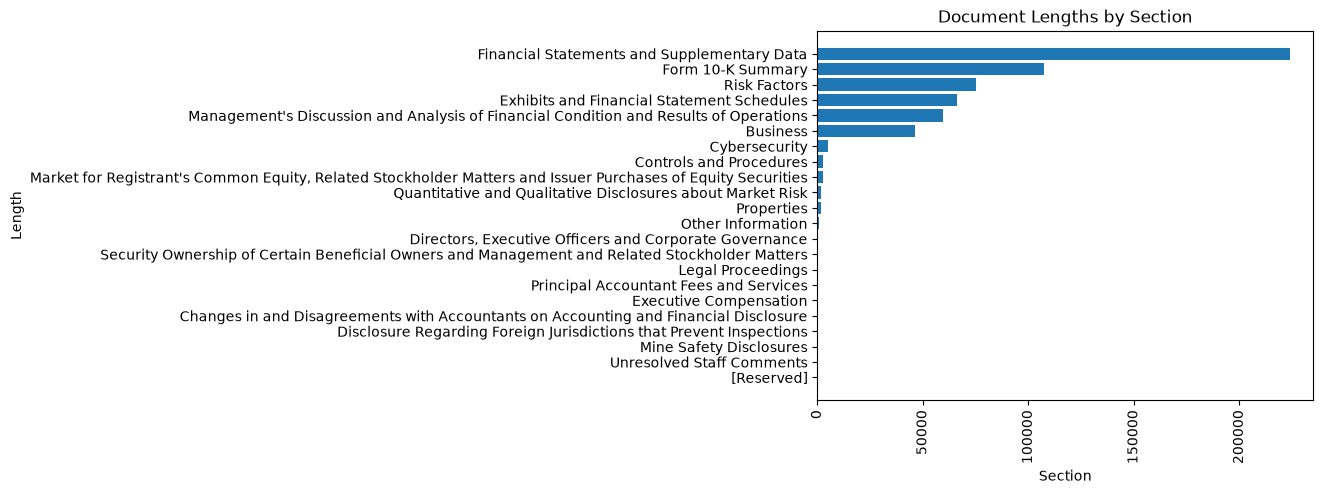

In [33]:
import matplotlib.pyplot as plt

# 각 섹션별로 문서 길이 확인
section_lengths = {section: len(doc.page_content) for section, doc in section_docs_combined.items()}

# 길이 순서로 정렬
section_lengths = dict(sorted(section_lengths.items(), key=lambda item: item[1]))

# 섹션별 문서 길이 시각화
plt.barh(section_lengths.keys(), section_lengths.values())
plt.xticks(rotation=90)
plt.xlabel("Section")
plt.ylabel("Length")
plt.title("Document Lengths by Section")
plt.show()

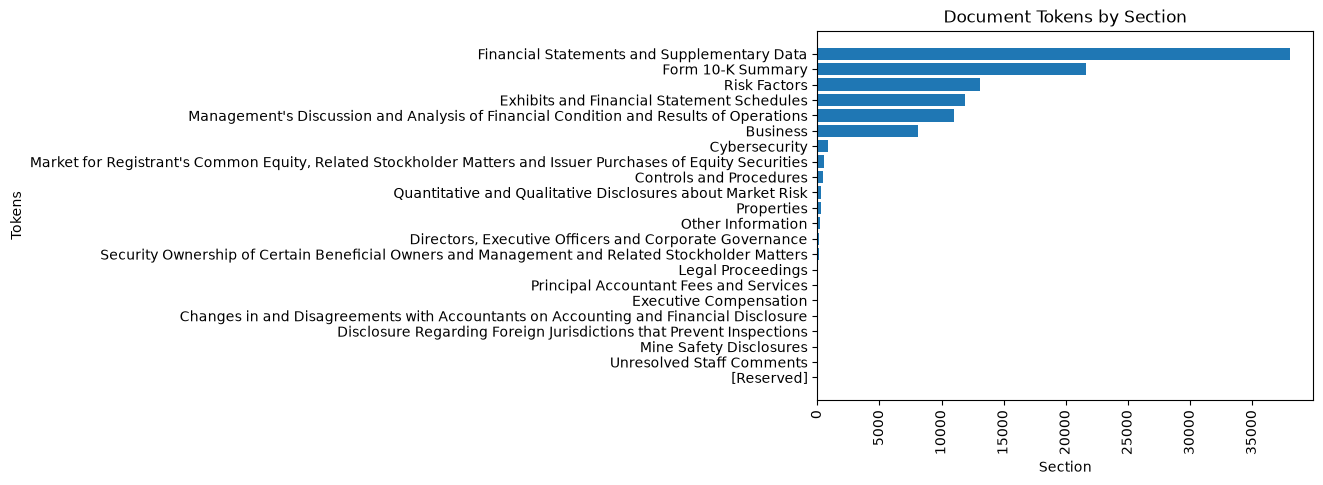

In [34]:
import tiktoken

# tiktoken tokenizer 초기화
tokenizer = tiktoken.get_encoding("cl100k_base")

# 각 섹션별로 토큰 수 확인
section_tokens = {section: len(tokenizer.encode(doc.page_content)) for section, doc in section_docs_combined.items()}

# 길이 순서로 정렬
section_tokens = dict(sorted(section_tokens.items(), key=lambda item: item[1]))

# 섹션별 토큰 수 시각화
plt.barh(section_tokens.keys(), section_tokens.values())
plt.xticks(rotation=90)
plt.xlabel("Section")
plt.ylabel("Tokens")
plt.title("Document Tokens by Section")
plt.show()

In [35]:
# 첫 번째 섹션의 메타데이터 확인
pprint(section_docs_combined['Business'].metadata)

{'end_page': 15,
 'page_count': 11,
 'section': 'Business',
 'section_number': 'Item 1',
 'start_page': 5}


In [ ]:
import re
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter


def extract_page_from_chunk(chunk_content: str, fallback_page: int) -> int:
    """청크 내용에서 [PAGE:N] 마커를 찾아 페이지 번호 추출"""
    matches = re.findall(r'\[PAGE:(\d+)\]', chunk_content)
    if matches:
        return int(matches[0])
    return fallback_page


def clean_page_markers(content: str) -> str:
    """청크 내용에서 [PAGE:N] 마커 제거"""
    return re.sub(r'\[PAGE:\d+\]\n?', '', content).strip()


# 토큰 기반 텍스트 분할기 설정
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", "? ", "! ", ". "]
)

# 섹션별 분할 ([PAGE:N] 마커에서 페이지 정보 추출)
section_docs_split = {}

for section_name, doc in section_docs_combined.items():
    start_page = doc.metadata['start_page']

    # 텍스트 분할
    split_docs = text_splitter.split_documents([doc])

    # 마지막으로 감지된 페이지 추적 (순차 처리)
    last_seen_page = start_page

    for i, split_doc in enumerate(split_docs):
        # [PAGE:N] 마커에서 페이지 번호 추출
        page = extract_page_from_chunk(split_doc.page_content, last_seen_page)
        last_seen_page = page

        # 마커 제거 후 메타데이터 설정
        split_doc.page_content = clean_page_markers(split_doc.page_content)
        split_doc.metadata = {
            'section': section_name,
            'page': page,
            'order': i + 1,
        }

    section_docs_split[section_name] = split_docs

# 결과 확인
total_chunks = sum(len(docs) for docs in section_docs_split.values())
print(f"총 청크 수: {total_chunks}")
print()
print("섹션별 청크 수:")
for section, chunks in section_docs_split.items():
    pages = sorted(set(c.metadata['page'] for c in chunks))
    page_range = f"p.{min(pages)}-{max(pages)}" if pages else "N/A"
    print(f"  {section}: {len(chunks)}개 ({page_range}, {len(pages)}개 페이지)")

📊 원형 보존 및 맥락 헤더가 적용된 표(Table) 개수: 83개

✅ 처리 완료!
- 총 청크 수: 387개
- 맥락 정보(Context)가 결합되어 보존된 표(Table) 수: 84개


In [66]:
# 1. 생성된 전체 청크 중 표(Table) 청크만 모으기
all_table_chunks = [
    chunk 
    for docs in section_docs_split.values() 
    for chunk in docs 
    if chunk.metadata.get('is_table')
]

print(f"🔍 총 {len(all_table_chunks)}개의 표 청크가 검색되었습니다.\n")

# 2. 상위 3개(또는 원하는 개수)의 표 청크 출력해보기
samples_to_show = 3

for i, chunk in enumerate(all_table_chunks[:samples_to_show], 1):
    print(f"==================== [ Table Chunk {i} ] ====================")
    print(f"📌 [Metadata]")
    print(f"  - Section : {chunk.metadata.get('section')}")
    print(f"  - Page    : {chunk.metadata.get('page')}")
    print(f"  - Order   : {chunk.metadata.get('order')}")
    print(f"  - Is Table: {chunk.metadata.get('is_table')}")
    print("-" * 60)
    print("📌 [Page Content]")
    print(chunk.page_content)
    print("=" * 60 + "\n")

🔍 총 84개의 표 청크가 검색되었습니다.

==================== [ Table Chunk 1 ] ====================
📌 [Metadata]
  - Section : Mine Safety Disclosures
  - Page    : 32
  - Order   : 2
  - Is Table: True
------------------------------------------------------------
📌 [Page Content]
[SECTION: Mine Safety Disclosures]
[SECTION: Legal Proceedings]
[SECTION: Properties]
[DOCUMENT CONTEXT]
- Page: 32
- Content Type: Financial/Structured Table
----------------------------------------
[TABLE DATA]
| Primary Manufacturing Facilities   | Location            | Owned or Leased   |
|:-----------------------------------|:--------------------|:------------------|
| Gigafactory Texas                  | Austin, Texas       | Owned             |
| Fremont Factory                    | Fremont, California | Owned             |
| Gigafactory Nevada                 | Sparks, Nevada      | Owned             |
| Gigafactory Berlin-Brandenburg     | Grunheide, Germany  | Owned             |
| Gigafactory Shanghai             

In [38]:
# 문서 객체를 pickle로 저장
with open("ref_data/docling_tesla_10k_sections_split.pkl", "wb") as f:
    pickle.dump(section_docs_split, f)

In [39]:
# pickle로 저장된 문서 객체 로드
from pathlib import Path

pickle_path = Path("ref_data/docling_tesla_10k_sections_split.pkl")

# 파일 존재 확인
if not pickle_path.exists():
    print(f"❌ 파일이 존재하지 않습니다: {pickle_path}")
    print("먼저 이전 셀을 실행하여 문서를 생성하고 저장하세요.")
else:
    with open(pickle_path, "rb") as f:
        section_docs_split = pickle.load(f)
    print(f"✅ 문서 로드 완료: {len([doc for docs in section_docs_split.values() for doc in docs])}개")

✅ 문서 로드 완료: 303개


In [40]:
section_docs_split

{'Business': [Document(metadata={'section': 'Business', 'page': 5, 'order': 1}, page_content="ITEM 1. BUSINESS\n\nOverview\n\nWe design, develop, manufacture, sell and lease high-performance fully electric vehicles and energy generation and storage systems, and offer services related to our products. We generally sell our products directly to customers, and continue to grow our customer-facing infrastructure through a global network of vehicle showrooms and service centers, Mobile Service, body shops, Supercharger stations and Destination Chargers to accelerate the widespread adoption of our products. We emphasize performance, attractive styling and the safety of our users and workforce in the design and manufacture of our products and are continuing to develop full self-driving technology for improved safety. We also strive to lower the cost of ownership for our customers through continuous efforts to reduce manufacturing costs and by offering financial and other services tailored to 

In [46]:
import os
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings

# 1. 텍스트 스플리터 (검색용 청크)
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=100,
    separators=["\n\n", "\n", r"(?<=[.!?])\s+"]
)

# 2. VectorStore 초기화
vectorstore = Chroma(
    collection_name="docling_tesla_10k_sections",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# 3. 문서 수집 (리스트 평탄화)
raw_documents = [
    doc
    for docs in section_docs_split.values()
    for doc in docs
]

# 4. 문서 분할 (Chunking)
split_docs = text_splitter.split_documents(raw_documents)

# 5. VectorStore에 저장
vectorstore.add_documents(split_docs)

# 6. 기본 Retriever 생성 (필요 시 RAG 파이프라인 연결)
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

In [51]:
# 1. 총 저장된 문서 수
print(f" Total documents in vectorstore: {vectorstore._collection.count()}")

# 2. 저장된 청크 데이터 2개 미리보기 (잘 쪼개졌는지 확인)
sample_docs = vectorstore.similarity_search("안내", k=5)

print("\n--- [저장된 청크 샘플 1] ---")
print(sample_docs[0].page_content[:300]) # 상위 300자 출력

if len(sample_docs) > 1:
    print("\n--- [저장된 청크 샘플 2] ---")
    print(sample_docs[2].page_content[:300])

 Total documents in vectorstore: 1418

--- [저장된 청크 샘플 1] ---
| 19               | Insider Trading Policy                                                                                                                                                                                                                                             | -                 

--- [저장된 청크 샘플 2] ---
TESLA, INC.

___________________

INSIDER TRADING POLICY

and

Guidelines with Respect to Certain Transactions in Securities


In [52]:
# Test 검색
query = "What are the main risk factors?"
retrieved_docs = retriever.invoke(query)

print(f"Retrieved {len(retrieved_docs)} documents\n")
for doc in retrieved_docs:
    section = doc.metadata.get('section', 'N/A')
    page = doc.metadata.get('page', 'N/A')
    order = doc.metadata.get('order', 'N/A')
    print(f"[Section: {section} | Page: {page} | Order: {order}]")
    print(doc.page_content[:500])
    print()
    print("=" * 100)

Retrieved 5 documents

[Section: Risk Factors | Page: 16 | Order: 1]
ITEM 1A. RISK FACTORS

You should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our business, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently known to us or that we currently deem to be immaterial also may materially adversely affect our business, financial condition and operating results.

Risks Related to O

[Section: Risk Factors | Page: 16 | Order: 1]
ITEM 1A. RISK FACTORS

You should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our business, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently known to us or that we currently deem to be immater

In [53]:
# 벡터 스토어 로드
vectorstore = Chroma(
    collection_name="docling_tesla_10k_sections",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# 로컬 파일 저장소 로드
storage_path = "./docling_document_store"
store = PickleFileStore(storage_path)


# # ParentDocumentRetriever 설정
# retriever = ParentDocumentRetriever(
#     vectorstore=vectorstore,
#     docstore=store,
#     child_splitter=child_splitter,
#     parent_splitter=parent_splitter,
# )

# Test 검색
query = "What are the main risk factors?"

retrieved_docs = retriever.invoke(query)
print(f"Retrieved {len(retrieved_docs)} documents")

for doc in retrieved_docs:
    print(doc.page_content[:500])
    print()
    print("=" * 100)

Retrieved 5 documents
ITEM 1A. RISK FACTORS

You should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our business, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently known to us or that we currently deem to be immaterial also may materially adversely affect our business, financial condition and operating results.

Risks Related to O

ITEM 1A. RISK FACTORS

You should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our business, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently known to us or that we currently deem to be immaterial also may materially adversely affect our business, financial condition and operating resu

In [54]:
# 다른 쿼리
query = "Where is Tesla's headquarters located?"

retrieved_docs = retriever.invoke(query)
print(f"Retrieved {len(retrieved_docs)} documents\n")

for doc in retrieved_docs:
    section = doc.metadata.get('section', 'N/A')
    page = doc.metadata.get('page', 'N/A')
    order = doc.metadata.get('order', 'N/A')
    print(f"[Section: {section} | Page: {page} | Order: {order}]")
    print(doc.page_content[:500])
    print()
    print("=" * 100)

Retrieved 5 documents

[Section: Form 10-K Summary | Page: 141 | Order: 40]
| Tesla Motors Limited                                                 | United Kingdom |
| Tesla Motors Luxembourg S.à r.l.                                     | Luxembourg     |
| Tesla Motors MA, Inc.                                                | Massachusetts  |
| Tesla Motors Netherlands B.V.                                        | Netherlands    |
| Tesla Motors New York LLC                                            | New York       |
| Tesla Motors NL LLC                             

[Section: Form 10-K Summary | Page: 141 | Order: 40]
| Tesla Motors Limited                                                 | United Kingdom |
| Tesla Motors Luxembourg S.à r.l.                                     | Luxembourg     |
| Tesla Motors MA, Inc.                                                | Massachusetts  |
| Tesla Motors Netherlands B.V.                                        | Netherlands    |
| Tesla M

### 5. **다중 벡터 기반 검색(Multi Vector Retrieval)**

- **Multi-Vector Retriever**는 문서를 **여러 벡터**로 분할하여 저장하고 검색하는 시스템
    1. 벡터 저장소(Vectorstore): 임베딩 저장
    2. 문서 저장소(Docstore): 원본 문서 저장

- 예제: **요약 기반 검색 시스템** 구현

    - 각 섹션의 간결한 요약문을 생성하여 벡터 저장소에 보관하고 유사도 검색에 활용함
    - **영구 저장소**는 PickleFileStore와 Chroma를 사용하여 문서와 벡터 데이터를 세션 간 유지함
    - **검색 과정**은 요약문으로 의미론적 매칭을 수행하고 전체 원본 문서를 반환하여 완전한 문맥을 제공함
    - **RAG 파이프라인**은 ChatGPT를 활용하여 요약 생성과 최종 답변을 처리하며 명확한 응답 형식을 제공함

In [55]:
from langchain_classic.retrievers import MultiVectorRetriever
from langchain_classic.storage import LocalFileStore
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import os
import pickle

# 로컬 파일 저장소 클래스 정의
class PickleFileStore(LocalFileStore):
    def mget(self, keys):
        return [pickle.loads(v) if v is not None else None 
                for v in super().mget(keys)]

    def mset(self, key_value_pairs):
        serialized_pairs = [(k, pickle.dumps(v)) for k, v in key_value_pairs]
        super().mset(serialized_pairs)

# 저장소 디렉토리 생성
os.makedirs("./summary_store", exist_ok=True)
os.makedirs("./chroma_db", exist_ok=True)

# 로컬 파일 저장소 초기화
doc_store = PickleFileStore("./summary_store")
vectorstore = Chroma(
    collection_name="tesla_10k_summaries",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# MultiVectorRetriever 설정
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=doc_store,
    id_key="doc_id"   # 문서 ID 키 설정
)

# 각 문서에 대한 요약 생성
def generate_summary(text):
    summary_prompt = ChatPromptTemplate.from_template(
        "Summarize the following 10-K report section in 2-3 sentences:\n\n{text}"
    )
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    summary_chain = summary_prompt | model | StrOutputParser()
    return summary_chain.invoke({"text": text})

# 요약된 문서 저장
summary_docs = []
original_docs = []
doc_ids = []

# 각 섹션별로 문서 결합
to_index_docs = [
        doc
        for docs in section_docs_split.values()
        for doc in docs
]

# 각 문서에 대한 요약 생성
for i, doc in enumerate(to_index_docs):
    doc_id = f"doc_{i}"
    summary = generate_summary(doc.page_content)

    # 요약 문서 생성 (페이지/순서 메타데이터 포함)
    summary_doc = Document(
        page_content=summary,
        metadata={
            "doc_id": doc_id,
            "section": doc.metadata["section"],
            "page": doc.metadata.get("page", 0),
            "order": doc.metadata.get("order", 1),
        }
    )
    summary_docs.append(summary_doc)

    # 원본 문서와 ID 저장
    original_docs.append(doc)
    doc_ids.append(doc_id)

# 벡터 스토어에 요약 문서 추가
retriever.vectorstore.add_documents(summary_docs)
retriever.docstore.mset(list(zip(doc_ids, original_docs)))

In [56]:
# 로컬 파일 저장소 로드
doc_store = PickleFileStore("./summary_store")
vectorstore = Chroma(
    collection_name="tesla_10k_summaries",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# 문서 개수 확인
print(f"Total documents in vectorstore: {vectorstore._collection.count()}")
all_keys = list(doc_store.yield_keys())
print(f"Total documents in store: {len(all_keys)}")

Total documents in vectorstore: 560
Total documents in store: 303


In [59]:
# RAG 체인 생성
rag_prompt = ChatPromptTemplate.from_template("""
Answer the following question based on the provided context from a 10-K report.
If you cannot find the answer in the context, say "제공된 문서에서 답을 찾을 수 없습니다."

<Context>
{context}
</Context>

<Question>
{question}
</Question>

<Answer>""")

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

chain = (
    {
        "context": retriever,
        "question": RunnablePassthrough()
    }
    | rag_prompt
    | model
    | StrOutputParser()
)

# 질문 생성
question = "What are the main risk factors?"
answer = chain.invoke(question, config={"callbacks": [langfuse_handler]})
print(f"\nQuestion: {question}")
print(f"Answer: {answer}")


Question: What are the main risk factors?
Answer: The main risk factors identified in the provided context are:

1. **Cybersecurity Risks**: Unauthorized access to or control of Tesla’s products, systems, or data could lead to legal claims, government investigations, reputational harm, and operational disruptions. Despite security measures, vulnerabilities and cyberattacks remain a significant risk.

2. **Labor and Union Risks**: Disruptions caused by union activities, including potential work stoppages or strikes, could delay manufacturing and sales. Tesla faces risks related to union organizing efforts, unfair labor practice charges, and dependency on suppliers and service providers with unionized workforces.

3. **Product Recalls and Safety Compliance**: Tesla may need to initiate voluntary or involuntary product recalls due to safety defects or non-compliance with regulations, which could result in significant expenses, supply chain complications, service burdens, and damage to br

---

## **실습 문제**

### **문제 1: 다른 섹션 질문 테스트**

다음 질문들로 RAG 시스템을 테스트해보세요:
- "Where is Tesla's headquarters located?"
- "What is Tesla's total revenue in 2024?"
- "Who are Tesla's competitors?"

각 질문에 대해 답변과 함께 **출처(섹션, 페이지)** 정보를 출력하세요.

In [ ]:
# 여기에 코드를 작성하세요
from langchain_core.runnables import RunnableParallel, RunnablePassthrough


# 1. 문서 출처 및 포맷팅 처리를 위한 헬퍼 함수
def format_docs_with_sources(docs):
    formatted_texts = []
    sources_info = []
    
    for i, doc in enumerate(docs, 1):
        formatted_texts.append(doc.page_content)
        
        # 원본 문서의 metadata에서 정보 추출
        section = doc.metadata.get("section", "N/A")
        page = doc.metadata.get("page", "N/A")
        
        sources_info.append(f"  - [문서 {i}] 섹션: {section} | 페이지: {page}")
    
    context_str = "\n\n".join(formatted_texts)
    sources_str = "\n".join(sources_info)
    
    return context_str, sources_str

# 2. RAG 체인 재구성 (답변과 검색 문서 객체 함께 전달)
rag_chain_with_sources = (
    RunnableParallel({
        "docs": retriever,
        "question": RunnablePassthrough()
    })
    | {
        "answer": (
            RunnablePassthrough.assign(
                context=lambda x: format_docs_with_sources(x["docs"])[0]
            )
            | rag_prompt
            | model
            | StrOutputParser()
        ),
        "sources": lambda x: format_docs_with_sources(x["docs"])[1]
    }
)

# 3. 테스트 질문 실행
test_questions = [
    "Where is Tesla's headquarters located?",
    "What is Tesla's total revenue in 2024?",
    "Who are Tesla's competitors?"
]

print("=== [다른 섹션 질문 테스트 결과] ===")

for q in test_questions:
    result = rag_chain_with_sources.invoke(
        q, 
        config={"callbacks": [langfuse_handler]}  # Langfuse 콜백 연결
    )
    
    print(f"\n❓ Question: {q}")
    print(f"💡 Answer: {result['answer']}")
    print(f"📌 Sources:\n{result['sources']}")
    print("-" * 50)

=== [다른 섹션 질문 테스트 결과] ===

❓ Question: Where is Tesla's headquarters located?
💡 Answer: 제공된 문서에서 답을 찾을 수 없습니다.
📌 Sources:
  - [문서 1] 섹션: Form 10-K Summary | 페이지: 141
  - [문서 2] 섹션: Form 10-K Summary | 페이지: 141
  - [문서 3] 섹션: Form 10-K Summary | 페이지: 141
  - [문서 4] 섹션: Form 10-K Summary | 페이지: 135
--------------------------------------------------

❓ Question: What is Tesla's total revenue in 2024?
💡 Answer: Tesla's total revenue in 2024 is $97.69 billion.
📌 Sources:
  - [문서 1] 섹션: Financial Statements and Supplementary Data | 페이지: 58
  - [문서 2] 섹션: Financial Statements and Supplementary Data | 페이지: 55
  - [문서 3] 섹션: Management's Discussion and Analysis of Financial Condition and Results of Operations | 페이지: 35
  - [문서 4] 섹션: Management's Discussion and Analysis of Financial Condition and Results of Operations | 페이지: 41
--------------------------------------------------

❓ Question: Who are Tesla's competitors?
💡 Answer: Tesla's competitors include:

- For vehicle offerings: other compa

<details>
<summary>정답 확인</summary>

```python
questions = [
    "Where is Tesla's headquarters located?",
    "What is Tesla's total revenue in 2024?",
    "Who are Tesla's competitors?"
]

for question in questions:
    answer = chain.invoke(question, config={"callbacks": [langfuse_handler]})
    print(f"\nQuestion: {question}")
    print(f"Answer: {answer}")

    # 검색된 문서의 출처(섹션, 페이지) 확인
    source_docs = retriever.invoke(question)
    sources = set()
    for doc in source_docs:
        section = doc.metadata.get("section", "N/A")
        page = doc.metadata.get("page", "N/A")
        sources.add(f"{section} (p.{page})")
    print(f"Sources: {', '.join(sorted(sources))}")
    print("=" * 80)
```

</details>

---

### **문제 2: 검색 k값 비교**

`MultiVectorRetriever`의 `search_kwargs`에서 `k` 값을 변경하여 검색 결과를 비교해보세요:
- k=3과 k=5로 각각 `MultiVectorRetriever`를 설정
- 동일한 질문에 대해 두 retriever로 RAG 체인을 구성하고 답변 비교
- 더 많은 문서를 참조할 때 답변이 어떻게 달라지는지 관찰

In [ ]:
# 여기에 코드를 작성하세요
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

# 1. k값별 Retriever 및 RAG 체인 생성 함수
def create_rag_chain_with_k(k_val):
    # search_kwargs로 k값 설정
    retriever_k = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=doc_store,
        id_key="doc_id",
        search_kwargs={"k": k_val}
    )
    
    chain = (
        RunnableParallel({
            "docs": retriever_k,
            "question": RunnablePassthrough()
        })
        | {
            "answer": (
                RunnablePassthrough.assign(
                    context=lambda x: "\n\n".join([doc.page_content for doc in x["docs"]])
                )
                | rag_prompt
                | model
                | StrOutputParser()
            ),
            "docs": lambda x: x["docs"]
        }
    )
    return chain

chain_k3 = create_rag_chain_with_k(3)
chain_k5 = create_rag_chain_with_k(5)

# 2. 비교 테스트 실행
test_questions = [
    "What are the main risk factors?",
    "Where is Tesla's headquarters located?",
    "What is Tesla's total revenue in 2024?"
]

print("=== [검색 k=3 vs k=5 비교 테스트] ===\n")

for q in test_questions:
    res_k3 = chain_k3.invoke(q, config={"callbacks": [langfuse_handler]})
    res_k5 = chain_k5.invoke(q, config={"callbacks": [langfuse_handler]})
    
    print(f"❓ Question: {q}\n")
    
    print(f"🔹 [k=3] 참조 문서 수: {len(res_k3['docs'])}개")
    print(f"   출처: {[doc.metadata.get('section', 'N/A') for doc in res_k3['docs']]}")
    print(f"   답변: {res_k3['answer']}\n")
    
    print(f"🔸 [k=5] 참조 문서 수: {len(res_k5['docs'])}개")
    print(f"   출처: {[doc.metadata.get('section', 'N/A') for doc in res_k5['docs']]}")
    print(f"   답변: {res_k5['answer']}\n")
    
    print("=" * 60)

=== [검색 k=3 vs k=5 비교 테스트] ===

❓ Question: What are the main risk factors?

🔹 [k=3] 참조 문서 수: 3개
   출처: ['Risk Factors', 'Risk Factors', 'Risk Factors']
   답변: <Answer>
주요 위험 요소는 다음과 같습니다:

1. 제품 및 시스템에 대한 무단 접근 또는 제어, 데이터 손실로 인한 법적 청구, 정부 조사 및 평판 손상 위험.
2. 노조 활동으로 인한 사업 중단 위험, 노조 가입에 따른 인건비 상승 및 작업 중단 가능성.
3. 제품 리콜 위험, 하드웨어 및 소프트웨어 관련 안전 문제 또는 규제 불이행으로 인한 비용 증가 및 브랜드 손상.
4. 보증 준비금 부족으로 인한 미래 보증 청구 비용 부담 가능성.
5. 정보기술(IT) 시스템 및 데이터에 대한 사이버 공격, 보안 사고로 인한 데이터 유출, 지적 재산권 도난, 법적·재정적 손실 및 평판 훼손 위험.
6. 핵심 인력, 특히 일론 머스크 CEO의 이탈 또는 시간 분산으로 인한 경영 리스크 및 인재 확보·유지의 어려움.
7. 공급망 공격 및 서비스 제공업체의 보안 취약성으로 인한 사업 운영 차질 위험.
8. IT 시스템 개발, 유지 및 확장 과정에서 발생할 수 있는 운영 중단, 내부 통제 결함 및 재무 보고 지연 위험.

이러한 위험 요소들은 회사의 브랜드, 사업 전망, 재무 상태 및 운영 결과에 부정적인 영향을 미칠 수 있습니다.
</Answer>

🔸 [k=5] 참조 문서 수: 5개
   출처: ['Risk Factors', 'Risk Factors', 'Risk Factors', 'Legal Proceedings', 'Risk Factors']
   답변: <Answer>
The main risk factors identified in the provided context are:

1. **Cybersecurity Risks**: Unauthorized access, contro

<details>
<summary>정답 확인</summary>

```python
from langchain_classic.retrievers import MultiVectorRetriever

# k=3으로 설정
retriever_k3 = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=doc_store,
    id_key="doc_id",
    search_kwargs={"k": 3}
)

# k=5로 설정
retriever_k5 = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=doc_store,
    id_key="doc_id",
    search_kwargs={"k": 5}
)

question = "What are the main risk factors?"

# k=3 결과
chain_k3 = (
    {"context": retriever_k3, "question": RunnablePassthrough()}
    | rag_prompt
    | model
    | StrOutputParser()
)
answer_k3 = chain_k3.invoke(question, config={"callbacks": [langfuse_handler]})

# k=5 결과
chain_k5 = (
    {"context": retriever_k5, "question": RunnablePassthrough()}
    | rag_prompt
    | model
    | StrOutputParser()
)
answer_k5 = chain_k5.invoke(question, config={"callbacks": [langfuse_handler]})

print("=== k=3 결과 ===")
print(answer_k3)
print("\n=== k=5 결과 ===")
print(answer_k5)
```

</details>

---

### **문제 3: 요약 프롬프트 수정**

`generate_summary` 함수의 프롬프트를 수정하여 더 상세한 요약을 생성해보세요:
- 3-5 문장으로 요약 길이 조정
- 특정 정보(숫자, 날짜 등)를 강조하도록 프롬프트 수정
- 원본 요약과 상세 요약 결과를 비교

In [ ]:
# 여기에 코드를 작성하세요
import pandas as pd
from langchain_core.documents import Document

# 1. 상세 요약 프롬프트 정의 및 생성 함수
def generate_detailed_summary(text):
    detailed_summary_prompt = ChatPromptTemplate.from_template(
        "Summarize the following 10-K report section in 3-5 sentences.\n"
        "Ensure you include and emphasize key quantitative details such as numbers, percentages, financial metrics, dates, and fiscal years:\n\n{text}"
    )
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    summary_chain = detailed_summary_prompt | model | StrOutputParser()
    return summary_chain.invoke({"text": text})

# 2. 비교 테스트 진행 (샘플 문서 2~3개 추출)
sample_docs = to_index_docs[:3]
comparison_results = []

for i, doc in enumerate(sample_docs):
    original_sum = generate_summary(doc.page_content)          # 기존 2~3문장 요약
    detailed_sum = generate_detailed_summary(doc.page_content) # 신규 3~5문장 수치 강조 요약
    
    comparison_results.append({
        "Doc Index": f"Doc #{i+1}",
        "Section": doc.metadata.get("section", "N/A"),
        "Original Summary (2-3 Sentences)": original_sum,
        "Detailed Summary (3-5 Sentences & Numbers Emphasized)": detailed_sum
    })

# 3. 결과 출력
print("=== [기존 요약 vs 상세 수치 강조 요약 비교] ===\n")
for res in comparison_results:
    print(f"📌 [{res['Doc Index']}] Section: {res['Section']}")
    print(f"🔹 [기존 요약]:\n{res['Original Summary (2-3 Sentences)']}\n")
    print(f"🔸 [상세 요약]:\n{res['Detailed Summary (3-5 Sentences & Numbers Emphasized)']}\n")
    print("-" * 70)

=== [기존 요약 vs 상세 수치 강조 요약 비교] ===

📌 [Doc #1] Section: Business
🔹 [기존 요약]:
The company designs, manufactures, and sells high-performance fully electric vehicles and energy generation and storage systems, supported by a global network of showrooms, service centers, and charging infrastructure. It operates through two main segments: automotive, which includes electric vehicles like the Model 3, Y, S, X, Cybertruck, and Tesla Semi, along with related services; and energy generation and storage, which offers products such as Powerwall, Megapack, solar energy systems, and the Solar Roof. The company focuses on innovation in full self-driving technology, battery development, and software to enhance product performance, safety, and customer experience while advancing its mission to accelerate the transition to sustainable energy.

🔸 [상세 요약]:
The company designs, manufactures, sells, and leases high-performance fully electric vehicles and energy generation and storage systems, operating throug

<details>
<summary>정답 확인</summary>

```python
def generate_detailed_summary(text):
    """3-5 문장으로 상세한 요약을 생성하며 숫자와 날짜를 강조"""
    detailed_summary_prompt = ChatPromptTemplate.from_template(
        """Summarize the following 10-K report section in 3-5 sentences.

        Focus on:
        - Key financial figures (revenue, profits, costs, etc.)
        - Important dates and time periods
        - Significant numbers and percentages
        - Major events or changes

        Text:
        {text}
        """
    )
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    summary_chain = detailed_summary_prompt | model | StrOutputParser()
    return summary_chain.invoke({"text": text})

# 첫 번째 문서로 테스트
test_doc = to_index_docs[0]

print("=== 원본 요약 ===")
print(generate_summary(test_doc.page_content))
print("\n=== 상세 요약 ===")
print(generate_detailed_summary(test_doc.page_content))
```

</details>

### **실습 : PDF 내 표(Table) 데이터를 손실 없이 HTML 및 맥락 헤더로 변환하고, LLM 요약 기반 Multi-Vector Retrieval을 적용하여 표 검색 정확도를 향상**

In [ ]:
import pickle
import re
from collections import defaultdict
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import tiktoken
from pydantic import BaseModel, Field

from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter


PKL_FILE_PATH = "ref_data/docling_output/tsla_analysis_ocr.pkl"  # elements 위치 경로 지정

with open(PKL_FILE_PATH, "rb") as f:
    elements = pickle.load(f)

print(f"📦 파일 로드 완료: 총 {len(elements)}개 element")


# 1. 헬퍼 함수 및 표 처리기 (HTML 변환 & Context Header 생성)
def extract_page_from_chunk(chunk_content: str, fallback_page: int) -> int:
    """청크 내용에서 [PAGE:N] 마커를 찾아 페이지 번호 추출"""
    matches = re.findall(r'\[PAGE:(\d+)\]', chunk_content)
    if matches:
        return int(matches[0])
    return fallback_page


def clean_page_markers(content: str) -> str:
    """청크 내용에서 [PAGE:N] 마커 제거"""
    return re.sub(r'\[PAGE:\d+\]\n?', '', content).strip()


def markdown_to_html_table(md_text: str) -> str:
    """Markdown 형태의 표를 Clean HTML <table> 구조로 변환"""
    lines = [line.strip() for line in md_text.strip().split('\n') if line.strip()]
    if not lines:
        return md_text
    
    html = ["<table border='1'>"]
    for i, line in enumerate(lines):
        if re.match(r'^[|:\s\-]+$', line): # 구분선 제거
            continue
        cells = [c.strip() for c in line.split('|')[1:-1]]
        if not cells:
            continue
            
        tag = "th" if i == 0 else "td"
        row_html = "  <tr>" + "".join(f"<{tag}>{c}</{tag}>" for c in cells) + "</tr>"
        html.append(row_html)
    html.append("</table>")
    return "\n".join(html)


def extract_tables_from_elements(ordered_json) -> List[Document]:
    """
    elements에서 표(Table) 데이터만 추출:
    1) HTML 포맷 변환
    2) Context Caption(맥락 헤더) 자동 합성
    3) 원형 보존용 독립 Document 생성
    """
    table_docs = []
    
    for item in ordered_json:
        item_type = item.get('type')
        page_num = item.get('page', 0)
        
        if item_type == 'table' and isinstance(item.get('content'), dict):
            table_md = item['content'].get('markdown', '').strip()
            if table_md:
                # [적용 1] HTML 포맷 변환
                table_html = markdown_to_html_table(table_md)
                
                # [적용 2] 표 상단 맥락 설명(Context Caption) 헤더 자동 생성
                context_header = (
                    f"[DOCUMENT CONTEXT]\n"
                    f"- Document: Tesla 10-K Report\n"
                    f"- Page: {page_num}\n"
                    f"- Format: HTML Structured Table\n"
                    f"----------------------------------------\n"
                )
                
                full_content = f"{context_header}[TABLE DATA]\n{table_html}"
                
                table_doc = Document(
                    page_content=full_content,
                    metadata={
                        'page': page_num,
                        'type': 'table',
                        'is_table': True,
                        'raw_table_html': table_html
                    }
                )
                table_docs.append(table_doc)
                
    return table_docs


📦 파일 로드 완료: 총 1513개 element


In [ ]:
# 2. 페이지별 문서 변환 (convert_by_page) - 표 제외, 텍스트만 추출
def convert_by_page_text_only(ordered_json):
    """페이지별 일반 텍스트만 수집하여 페이지 단위 Document 생성"""
    pages = {}
    for item in ordered_json:
        page_num = item.get('page', None)
        if page_num is not None and item.get('type') == 'text':
            if page_num not in pages:
                pages[page_num] = []
            pages[page_num].append(item)
    
    documents = []
    for page_num, items in sorted(pages.items()):
        contents = []
        for item in items:
            text = item.get('content', '').strip()
            if text:
                for exclude_text in ["Table of Contents", "TABLE OF CONTENTS"]:
                    if exclude_text in text:
                        text = text.replace(exclude_text, '').strip()
                        break
                if text:
                    contents.append(text)
        
        if contents:
            doc = Document(
                page_content='\n\n'.join(contents).strip(),
                metadata={'page': page_num, 'elements_count': len(items)}
            )
            documents.append(doc)
            
    return documents

docs_by_page = convert_by_page_text_only(elements)
print(f"✅ 페이지별 변환 완료 (일반 텍스트): {len(docs_by_page)}개 Document")

✅ 페이지별 변환 완료 (일반 텍스트): 123개 Document


In [ ]:

# 3. LLM 기반 TOC 목차 구조 추출 및 매핑
class Item(BaseModel):
    number: str = Field(description="목차 항목 번호 (예: 1, 1A, 2 등)")
    title: str = Field(description="목차 항목 제목")
    page: int = Field(description="목차 항목이 위치한 페이지 번호")

class Section(BaseModel):
    section: str = Field(description="목차 섹션 그룹")
    items: List[Item] = Field(description="목차 항목 리스트")

class TOCStructure(BaseModel):
    sections: List[Section] = Field(description="목차 섹션 리스트")

toc_extraction_prompt = PromptTemplate(
    input_variables=["table_text"],
    template="""
You are an expert document analyzer specializing in extracting table of contents information from financial documents.
Analyze the following table of contents text and extract structured information.

Table of Contents Text:
{table_text}
"""
)

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
toc_extractor = toc_extraction_prompt | llm.with_structured_output(TOCStructure)

# 목차 페이지(예: Index 2번 페이지) 분석
toc_page_content = docs_by_page[2].page_content if len(docs_by_page) > 2 else docs_by_page[0].page_content
toc_sections = toc_extractor.invoke(toc_page_content)

item_list = []
for sec in toc_sections.sections:
    for it in sec.items:
        item_list.append({'number': it.number, 'title': it.title, 'page': it.page})


In [ ]:
# 4. TOC 기반 문서 Split & Section 병합 (유연한 매칭 및 Fallback 적용)
def normalize_text(text: str) -> str:
    """공백 및 특수문자를 제거하여 유연한 매칭을 위한 문자열 정규화"""
    return re.sub(r'[^a-zA-Z0-9가-힣]', '', text).lower()

def find_all_section_positions(page_content: str, item_list: List[Dict]) -> List[Tuple[int, Dict]]:
    section_positions = []
    norm_page_content = normalize_text(page_content)
    
    for item in item_list:
        item_no = item['number'].strip()
        item_title = item['title'].strip()
        
        # 1. 키워드 생성 (예: "ITEM 1A. RISK FACTORS", "1A. RISK FACTORS", "RISK FACTORS")
        headers = [
            f"ITEM{item_no}{item_title}",
            f"{item_no}{item_title}",
            f"ITEM{item_no}",
            item_title
        ]
        
        for h in headers:
            norm_header = normalize_text(h)
            if norm_header and norm_header in norm_page_content:
                # 대략적인 시작 위치 추정
                idx = page_content.lower().find(item_title.lower()[:10])
                if idx == -1:
                    idx = 0
                section_positions.append((idx, item))
                break
                
    section_positions.sort(key=lambda x: x[0])
    return section_positions

def process_documents_with_toc(docs_by_page: List[Document], item_list: List[Dict]) -> List[Document]:
    section_boundaries = []
    for i, doc in enumerate(docs_by_page):
        positions = find_all_section_positions(doc.page_content, item_list)
        for pos, item in positions:
            section_boundaries.append({'page_index': i, 'position': pos, 'item': item})
            
    toc_based_docs = []
    for doc_idx, doc in enumerate(docs_by_page):
        prev_sections = [sb for sb in section_boundaries if sb['page_index'] <= doc_idx]
        
        # 이전 섹션이 존재하면 해당 섹션 할당, 없으면 General Document로 분류
        current_item = prev_sections[-1]['item'] if prev_sections else {'title': 'General Document', 'number': '0'}
        
        doc_copy = Document(
            page_content=doc.page_content,
            metadata={
                **doc.metadata,
                "section": current_item['title'],
                "section_number": current_item['number']
            }
        )
        toc_based_docs.append(doc_copy)
    return toc_based_docs

toc_based_docs = process_documents_with_toc(docs_by_page, item_list)

# 섹션별 텍스트 병합 (Preamble/General Document도 포함하여 유실 방지)
section_groups = defaultdict(list)
for doc in toc_based_docs:
    sec = doc.metadata.get('section', 'General Document')
    section_groups[sec].append(doc)

section_docs_combined = {}
for section_name, docs in section_groups.items():
    page_contents = []
    for doc in sorted(docs, key=lambda d: d.metadata.get('page', 0)):
        p_num = doc.metadata.get('page', 0)
        page_contents.append(f"[PAGE:{p_num}]\n{doc.page_content}")
        
    pages = [d.metadata.get('page', 0) for d in docs]
    section_docs_combined[section_name] = Document(
        page_content="\n\n".join(page_contents),
        metadata={
            'section': section_name,
            'section_number': docs[0].metadata.get('section_number', ''),
            'start_page': min(pages),
            'end_page': max(pages),
        }
    )

print(f"✅ 섹션 병합 완료: 총 {len(section_docs_combined)}개 섹션 감지")

✅ 섹션 병합 완료: 총 2개 섹션 감지


In [ ]:
# 5. 표(Table) 1차 추출 & [적용 3] 표 전용 LLM 요약 생성 (Multi-Vector 준비)
table_docs = extract_tables_from_elements(elements)
print(f"📊 원형 보존/HTML 변환 표(Table) 개수: {len(table_docs)}개")

summary_prompt = PromptTemplate(
    input_variables=["table_html"],
    template="""
Analyze the following HTML table and generate a concise summary describing its key metrics, variables, financial figures, and main takeaway for search retrieval.

HTML Table:
{table_html}

Summary:
"""
)
summary_chain = summary_prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("⚡ 표 전용 요약(Summary) 생성 중...")
for t_doc in table_docs:
    raw_html = t_doc.metadata.get('raw_table_html', t_doc.page_content)
    table_summary = summary_chain.invoke({"table_html": raw_html}).content.strip()
    
    # [멀티벡터 리트리버 핵심 설정]
    t_doc.metadata['summary'] = table_summary  # 벡터 스토어 인덱싱용 요약문
    t_doc.metadata['doc_id'] = f"table_{t_doc.metadata['page']}_{id(t_doc)}"

📊 원형 보존/HTML 변환 표(Table) 개수: 83개
⚡ 표 전용 요약(Summary) 생성 중...


In [ ]:
# 6. 토큰 기반 Split 및 표/텍스트 최종 결합 (section_docs_split)
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", "? ", "! ", ". "]
)

section_docs_split = {}
assigned_table_ids = set() # 이미 매핑된 표 추적용

for section_name, doc in section_docs_combined.items():
    start_page = doc.metadata['start_page']
    end_page = doc.metadata['end_page']

    # A. 일반 텍스트 토큰 분할
    split_docs = text_splitter.split_documents([doc])
    
    last_seen_page = start_page
    final_section_chunks = []

    for i, split_doc in enumerate(split_docs):
        page = extract_page_from_chunk(split_doc.page_content, last_seen_page)
        last_seen_page = page

        split_doc.page_content = clean_page_markers(split_doc.page_content)
        split_doc.metadata = {
            'section': section_name,
            'page': page,
            'order': i + 1,
            'is_table': False
        }
        final_section_chunks.append(split_doc)

    # B. 해당 섹션 범위(start_page ~ end_page)의 표(Table) 원본 결합
    for table_doc in table_docs:
        tbl_page = table_doc.metadata['page']
        tbl_id = table_doc.metadata.get('doc_id')
        
        if start_page <= tbl_page <= end_page:
            table_copy = Document(
                page_content=table_doc.page_content,
                metadata={**table_doc.metadata}
            )
            table_copy.metadata['section'] = section_name
            table_copy.metadata['order'] = len(final_section_chunks) + 1
            
            if not table_copy.page_content.startswith("[SECTION:"):
                table_copy.page_content = f"[SECTION: {section_name}]\n" + table_copy.page_content
            
            final_section_chunks.append(table_copy)
            assigned_table_ids.add(tbl_id)

    section_docs_split[section_name] = final_section_chunks

# C. 섹션 범위에 포함되지 못한 남은 표들(Fallback)을 해당 페이지 섹션에 매핑
unassigned_tables = [t for t in table_docs if t.metadata.get('doc_id') not in assigned_table_ids]
if unassigned_tables:
    if "General Document" not in section_docs_split:
        section_docs_split["General Document"] = []
    for t_doc in unassigned_tables:
        t_doc.metadata['section'] = "General Document"
        section_docs_split["General Document"].append(t_doc)

In [ ]:

# 7. 최종 검증 및 예시 확인
total_chunks = sum(len(docs) for docs in section_docs_split.values())
total_tables = sum(1 for docs in section_docs_split.values() for d in docs if d.metadata.get('is_table'))

print(f"\n✅ 파이프라인 처리 완료!")
print(f"- 총 청크 수: {total_chunks}개")
print(f"- 원형 보존 및 요약 정보가 부착된 표(Table) 수: {total_tables}개\n")

# 생성된 표 청크 샘플 검증
all_table_chunks = [c for docs in section_docs_split.values() for c in docs if c.metadata.get('is_table')]

if all_table_chunks:
    sample = all_table_chunks[0]
    print("==================== [ Multi-Vector 표 청크 검증 예시 ] ====================")
    print(f"📌 [Metadata]")
    print(f"  - Section   : {sample.metadata.get('section')}")
    print(f"  - Page      : {sample.metadata.get('page')}")
    print(f"  - Is Table  : {sample.metadata.get('is_table')}")
    print(f"  - Summary   : {sample.metadata.get('summary')}")
    print("-" * 70)
    print(f"📌 [Page Content (원형 보존 HTML + 맥락 헤더)]:\n{sample.page_content[:400]}...")
    print("==========================================================================")


✅ 파이프라인 처리 완료!
- 총 청크 수: 187개
- 원형 보존 및 요약 정보가 부착된 표(Table) 수: 83개

==================== [ Multi-Vector 표 청크 검증 예시 ] ====================
📌 [Metadata]
  - Section   : General Document
  - Page      : 1
  - Is Table  : True
  - Summary   : The HTML table presents information about a financial asset, specifically a class of stock. Key metrics and variables include:

- **Title of Class**: Common stock
- **Trading Symbol**: TSLA
- **Exchange**: The Nasdaq Global Select Market

**Main Takeaway**: The table indicates that Tesla, Inc. (TSLA) is listed on the Nasdaq Global Select Market, highlighting its status as a publicly traded company. This information is essential for investors and analysts tracking stock performance and market activity.
----------------------------------------------------------------------
📌 [Page Content (원형 보존 HTML + 맥락 헤더)]:
[SECTION: General Document]
[DOCUMENT CONTEXT]
- Document: Tesla 10-K Report
- Page: 1
- Format: HTML Structured Table
------------------------

In [78]:
import os
from typing import List
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

# 1. 벡터 스토어 구축용 데이터 변환 (Multi-Vector 전략 적용)
# section_docs_split에서 모든 청크(일반 텍스트 + 표)를 평탄화(Flat)
all_chunks: List[Document] = [
    chunk 
    for chunks in section_docs_split.values() 
    for chunk in chunks
]

indexing_docs = []

for chunk in all_chunks:
    if chunk.metadata.get('is_table'):
        # 📌 표(Table)인 경우:
        # 벡터 검색에는 LLM 요약문(summary) + 섹션/페이지 정보만 임베딩
        # 실제 검색 결과(page_content)는 원본 HTML 표를 담아서 보관
        summary_text = chunk.metadata.get('summary', '')
        section_name = chunk.metadata.get('section', '')
        page_num = chunk.metadata.get('page', 0)
        
        # 검색용 텍스트 (요약 + 맥락)
        searchable_content = f"[SECTION: {section_name}] [PAGE: {page_num}]\nSummary: {summary_text}"
        
        indexed_doc = Document(
            page_content=searchable_content, # 🔍 Vector DB 검색용 (Summary)
            metadata={
                **chunk.metadata,
                'raw_content': chunk.page_content # 📄 LLM 전달용 (Original HTML Table)
            }
        )
        indexing_docs.append(indexed_doc)
    else:
        # 📌 일반 텍스트인 경우: 그대로 임베딩
        indexing_docs.append(chunk)

print(f"📦 총 {len(indexing_docs)}개 문서 인덱싱 준비 완료 (표 포함)")


# 2. Vector DB 생성 (Chroma DB)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

CHROMA_DB_DIR = "./chroma_db"

# Chroma DB 생성 및 임베딩 저장
vectorstore = Chroma.from_documents(
    documents=indexing_docs,
    embedding=embeddings,
    collection_name="tesla_10k_tables",
    persist_directory=CHROMA_DB_DIR  # 디스크 저장 경로
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("✅ Chroma Vector DB 구축 완료!\n")


# 3. 검색 테스트 함수
def test_table_retrieval(query: str):
    print("=" * 80)
    print(f"🔍 [검색 질문]: \"{query}\"")
    print("=" * 80)
    
    results = retriever.invoke(query)
    
    for i, doc in enumerate(results, 1):
        is_table = doc.metadata.get('is_table', False)
        section = doc.metadata.get('section', 'N/A')
        page = doc.metadata.get('page', 'N/A')
        
        print(f"\n Top {i} 결과 [타입: {'📊 표(Table)' if is_table else '📝 일반 텍스트'}]")
        print(f"📍 위치: Section '{section}', Page {page}")
        
        if is_table:
            print(f"💡 [Vector DB가 찾은 요약문 (Index)]:\n{doc.page_content}")
            print("-" * 50)
            print(f"📄 [LLM에게 보낼 실제 원본 (Payload - HTML)]:\n{doc.metadata.get('raw_content')[:300]}...\n")
        else:
            print(f"📄 [본문 내용]:\n{doc.page_content[:300]}...\n")

# 4. 테스트 질문 실행
test_table_retrieval("What was the revenue or financial figures reported in the tables?")

📦 총 187개 문서 인덱싱 준비 완료 (표 포함)
✅ Chroma Vector DB 구축 완료!

🔍 [검색 질문]: "What was the revenue or financial figures reported in the tables?"

 Top 1 결과 [타입: 📊 표(Table)]
📍 위치: Section 'Signatures', Page 84
💡 [Vector DB가 찾은 요약문 (Index)]:
[SECTION: Signatures] [PAGE: 84]
Summary: The HTML table presents financial data for three consecutive years ending December 31, from 2022 to 2024. Key metrics include:

- **Domestic Revenue**: 
  - 2024: $2,292
  - 2023: $3,196
  - 2022: $5,524
  - **Trend**: Significant decline in domestic revenue over the three years.

- **Noncontrolling Interest and Redeemable Noncontrolling Interest**: 
  - 2024: $62
  - 2023: $(23) (indicating a loss)
  - 2022: $31
  - **Trend**: Fluctuating values with a notable loss in 2023.

- **Foreign Revenue**: 
  - 2024: $6,636
  - 2023: $6,800
  - 2022: $8,164
  - **Trend**: A slight decrease in foreign revenue, but less pronounced than domestic.

- **Income Before Income Taxes**: 
  - 2024: $8,990
  - 2023: $9,973
  - 2022: $13,